--- Step 1 & 2: Raw Data ---
[[ 2. 50.]
 [ 9. 95.]
 [ 5. 70.]
 [ 8. 90.]
 [ 3. 60.]]


--- Step 3: Standardized Data ---
[[-1.24650048 -1.33684785]
 [ 1.31982404  1.27872403]
 [-0.14664712 -0.17437146]
 [ 0.95320625  0.98810493]
 [-0.87988269 -0.75560965]]


--- Step 4: Covariance Matrix (2x2) ---
[[1.25       1.24658972]
 [1.24658972 1.25      ]]


--- Step 5: Sorted Eigenvectors ---
[[ 0.70710678+0.j -0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j]]


--- Step 6: Final Projected 1D Data ---
[[-1.82670312+0.j]
 [ 1.83745096+0.j]
 [-0.22699441+0.j]
 [ 1.3727143 +0.j]
 [-1.15646773+0.j]]




c:\Users\anits-csm\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\anits-csm\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\collections.py:205: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


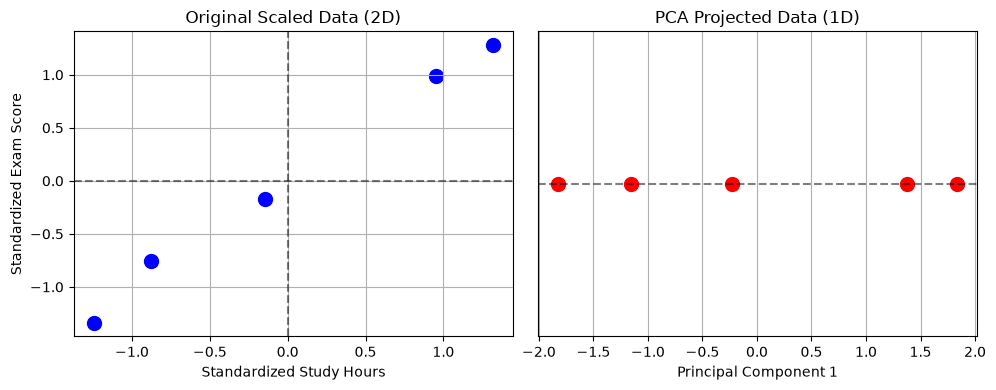

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# Step 1 & 2: Define Raw Dataset (Study Hours vs Exam Score)
# =====================================================================
X = np.array([[2, 50], [9, 95], [5, 70], [8, 90], [3, 60]], dtype=float)

print("--- Step 1 & 2: Raw Data ---")
print(X)
print("\n")

# =====================================================================
# Step 3: Standardize the Data Manually
# =====================================================================
mean = np.mean(X, axis=0)
std_dev = np.std(X, axis=0)
X_scaled = (X - mean) / std_dev

print("--- Step 3: Standardized Data ---")
print(X_scaled)
print("\n")

# =====================================================================
# Step 4: Compute the Covariance Matrix
# =====================================================================
# We use .T (transpose) because np.cov expects features as rows
cov_matrix = np.cov(X_scaled.T)

print("--- Step 4: Covariance Matrix (2x2) ---")
print(cov_matrix)
print("\n")

# =====================================================================
# Step 5: Compute & Sort Eigenvalues and Eigenvectors
# =====================================================================
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues in descending order and match eigenvectors
sorted_idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

print("--- Step 5: Sorted Eigenvectors ---")
print(eigen_vectors)
print("\n")

# =====================================================================
# Step 6: Select Top-k Components & Project the Data (Your Dot Product!)
# =====================================================================
# We compress 2D down to 1D (k = 1)
k = 1
principal_components = eigen_vectors[:, :k]

# Dot product of (5, 2) scaled data and (2, 1) eigenvectors
X_projected = np.dot(X_scaled, principal_components)

print("--- Step 6: Final Projected 1D Data ---")
print(X_projected)
print("\n")

# =====================================================================
# Visualization (Plotting the original 2D vs the 1D PCA line)
# =====================================================================
plt.figure(figsize=(10, 4))

# Left plot: Original 2D scaled data
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], color="blue", s=100)
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.axvline(0, color="black", linestyle="--", alpha=0.5)
plt.title("Original Scaled Data (2D)")
plt.xlabel("Standardized Study Hours")
plt.ylabel("Standardized Exam Score")
plt.grid(True)

# Right plot: Projected 1D data along a single line
plt.subplot(1, 2, 2)
plt.scatter(X_projected, np.zeros_like(X_projected), color="red", s=100)
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.title("PCA Projected Data (1D)")
plt.xlabel("Principal Component 1")
plt.yticks([])  # Hide y-axis since it is 1D
plt.grid(True)

plt.tight_layout()
plt.show()